In [1]:
%%capture
!pip install osmnx
!pip install geopandas

#!pip install dask_geopandas
!pip install branca;
!pip install folium>=0.12;
!pip install mapclassify;
!pip install h3;

In [20]:
from matplotlib import cm
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

import osmnx as ox
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

import matplotlib as mpl

import folium
import h3
import branca.colormap as cmbranca

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)


def coefficient_of_variation(data):
    data = np.array(data)
    mean = np.mean(data)
    if mean == 0:
        return np.nan  # Avoid division by zero
    std_dev = np.std(data, ddof=1)  # sample standard deviation
    cv = (std_dev / mean) * 100
    return cv


def plot_map_gdf(gdf, col, log_transform=True, figsize=(10, 10),
    cmap="Blues", alpha=1, ax=None, fig=None, th=0,
    show_cbar=True, vmin=None, vmax=None):

    # Filter data
    plot_gdf = gdf[gdf[col] > th].copy()

    # Apply transformation
    if log_transform:
        plot_gdf["_plot_val"] = np.log10(1 + plot_gdf[col])
        label = f"log10(1 + {col})"
        transform = lambda x: np.log10(1 + x)
    else:
        plot_gdf["_plot_val"] = plot_gdf[col]
        label = col
        transform = lambda x: x

    values = plot_gdf["_plot_val"]

    # Create figure/axis if needed
    if ax is None and fig is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Determine coherent vmin/vmax in transformed space
    if vmin is None:
        vmin_plot = values.min()
    else:
        vmin_plot = transform(vmin)

    if vmax is None:
        vmax_plot = values.max()
    else:
        vmax_plot = transform(vmax)

    # Plot map using SAME normalization
    plot_gdf.plot(
        column="_plot_val",
        cmap=cmap,
        legend=False,
        ax=ax,
        alpha=alpha,
        vmin=vmin_plot,
        vmax=vmax_plot,
    )

    cbar = None

    # Create matching colorbar
    if show_cbar:
        norm = plt.Normalize(vmin=vmin_plot, vmax=vmax_plot)
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []

        cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.1, orientation="horizontal",)
        cbar.set_label(label)

    return fig, ax, cbar    

def plot_time_series(df_plot, axes=None, color="k", plot_avg=False, label=""):
    
    if axes is None:
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

    axes[0].plot(df_plot["date"], df_plot["n_points_count"], c=color, linewidth=1, label=label, marker=".")
    if plot_avg:
        axes[0].axhline(np.mean(df_plot["n_points_count"]), c=color, linewidth=1, linestyle=":")
    axes[0].set_ylabel("GPS observations", weight=600);
    
    axes[1].plot(df_plot["date"], df_plot["uid_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[1].axhline(np.mean(df_plot["uid_unique"]), c=color, linewidth=1, linestyle=":")
    axes[1].set_ylabel("Active users", weight=600);
    
    axes[2].plot(df_plot["date"], df_plot["hex_id_unique"], c=color, linewidth=1, marker=".")
    if plot_avg:
        axes[2].axhline(np.mean(df_plot["hex_id_unique"]), c=color, linewidth=1, linestyle=":")
    axes[2].set_ylabel("Visited hexes", weight=600);
    
    for ax in axes:
        ax.tick_params(axis='x', labelsize=8)
        # Set major ticks every 2 days
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        # Optional: format how the date appears
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    return axes

In [3]:
import h3
from shapely.geometry import shape

In [13]:
def gdf_to_h3(gdf, resolution):
    """
    Convert a GeoDataFrame of polygons to Uber H3 cells at a given resolution.
    """
    # ensure in lat/lon
    gdf = gdf.to_crs(epsg=4326)

    # collect unique H3 cell ids covering all input geometries
    h3_ids = set()
    for geom in gdf.geometry:
        cells = h3.geo_to_cells(geom, resolution)
        h3_ids.update(cells)

    # convert H3 cells to geojson‑style and then to Shapely polygons
    hex_geoms = []
    hex_ids = []
    for h in h3_ids:
        # cells_to_geo returns a __geo_interface__‑like dict for the cell(s)
        geojson = h3.cells_to_geo([h])
        # shape(...) converts geojson dict to shapely geometry
        poly = shape(geojson)
        hex_geoms.append(poly)
        hex_ids.append(h)

    # make GeoDataFrame
    h3_gdf = gpd.GeoDataFrame(
        {"h3_index": hex_ids},
        geometry=hex_geoms,
        crs="EPSG:4326"
    )

    return h3_gdf

In [14]:
def min_max_normalize_range(data, new_min=0, new_max=1):
    min_val = min(data)
    max_val = max(data)
    
    if max_val == min_val:
        return [new_min for _ in data]
    
    return [
        new_min + (x - min_val) * (new_max - new_min) / (max_val - min_val)
        for x in data
    ]

# Urban Activity Dynamics During Republic Day in Istanbul

In this case study, we apply our methodology to anonymized mobility data from Veraset to assess the impact of a large, planned public event on urban activity  patterns. Understanding how populations visit urban areas during such events provides valuable insights for urban planning, infrastructure management, and emergency preparedness.
We focus on **Republic Day in Istanbul (29 October 2023)**, a major national holiday in Turkey marked by large public gatherings, celebrations, and increased activity across urban spaces. Using the **Urban Space Usage Index**, we identify deviations from typical activity patterns and examine how different areas of the city respond to the event.

## 1. Data

### 1.1 Mobility Dataset
The analysis is based on the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. The dataset consists of anonymized mobile device location pings collected via a network of mobile applications and software development kits (SDKs). Each record includes geographic coordinates, a timestamp, and an anonymized device identifier. These data provide large-scale observations of human mobility, enabling the analysis of spatial and temporal patterns of urban activity.

In [6]:
H3_res = 8

dataset_name = "dataset_republicday_istanbul_1oct_14nov"
# Define the analysis period
#FROM_DATE = pd.to_datetime("2023-10-01")
FROM_DATE = pd.to_datetime("2023-10-02")
TO_DATE = pd.to_datetime("2023-11-14")

EVENT_START = pd.to_datetime("2023-10-28 00:00")
EVENT_END = pd.to_datetime("2023-10-29 23:59")


print("ANALYSIS CONFIGURATION SUMMARY")
print("="*50)
print(f"Scenario        : Republic Day")
print(f"Dataset         : {dataset_name}")
print(f"H3 Resolution   : {H3_res}")
print(f"Start Date      : {FROM_DATE.strftime('%Y-%m-%d')}")
print(f"End Date        : {TO_DATE.strftime('%Y-%m-%d')}")
print(f"Total Days      : {(TO_DATE - FROM_DATE).days + 1}")
print("="*50 + "\n")

ANALYSIS CONFIGURATION SUMMARY
Scenario        : Republic Day
Dataset         : dataset_republicday_istanbul_1oct_14nov
H3 Resolution   : 8
Start Date      : 2023-10-02
End Date        : 2023-11-14
Total Days      : 44



### 1.2 Area of Interest (AOI)

The analysis focuses on Istanbul, Turkey. The study area is defined using an administrative boundary shapefile (Figure 1, [source](https://github.com/ozanyerli/istanbul-districts-geojson/blob/main/istanbul-districts.json)).

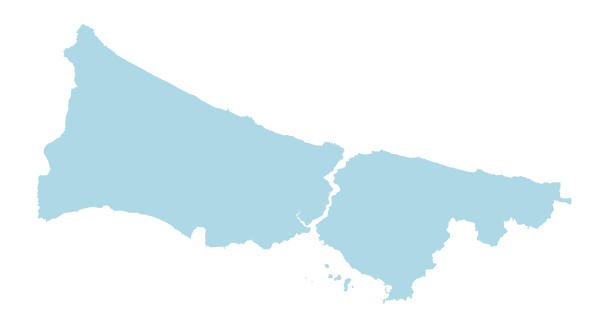

In [7]:
# AOI

#Istanbul shapefile from https://github.com/ozanyerli/istanbul-districts-geojson/blob/main/istanbul-districts.json
gdf_AOI = gpd.read_file("./shape_files/istanbul-districts.json")
gdf_AOI = gdf_AOI.dissolve()

minx, miny, maxx, maxy = gdf_AOI.total_bounds
fig, ax = plt.subplots(figsize=(8,4))
gdf_AOI.plot(ax=ax, color='lightblue', edgecolor=None)
ax.axis("off");

**Figure 1.** Administrative boundary of Istanbul used to define the area of interest (AOI). All mobility data are spatially clipped to this region and aggregated using the H3 hierarchical grid system.

| Res | Average Hexagon Area (km²) |
|-----|----------------------------|
| ... | ...                        |
| 6   | 36.129062164               |
| 7   | 5.161293360                |
| 8   | 0.737327598                |
| 9   | 0.105332513                |
| ... | ...                        |

In [8]:
output_path = Path(f"./spatial_tessellations/gdf_h3_res{H3_res}_REPUBLICDAY.gpkg")

if output_path.exists():
    print("File exists. Loading...")
    gdf_h3 = gpd.read_file(output_path)
else:
    print("File not found. Computing and saving...")
    crs = gdf_AOI.crs
    gdf_h3 = gdf_to_h3(
        gdf_AOI.buffer(0.05).to_crs(crs),
        H3_res
    )
    print(len(gdf_h3))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf_h3.to_file(output_path, driver="GPKG")

File exists. Loading...


In [9]:
gdf_h3[:1]

,h3_index,geometry
0,881ec91131fffff,"POLYGON ((28.85366 41.03196, 28.84695 41.03154..."


We spatially discretize the area of interest using the H3 Uber hierarchical indexing at resolution 8. This corresponds to hexagonal cells of approximately 0.737 km². Each H3 cell (or hexagon) represents the spatial unit of the analysis.

In [10]:
gdf_h3[gdf_h3["h3_index"]=="881ec90247fffff"].explore(zoom_start=15)

### 1.3 Time window and study periods

To capture mobility dynamics before, during, and after **Republic Day**, which occurs from **13.00 on 28 October to all 29 October**, we extract data for the period 2 October to 10 November 2023, spatially clipped to the study area (see Figure 2).

We define three analysis periods:
- **Baseline period**: 2-27 October
- **Event period**: 28-29 October
- **Post-event period**: 30 October - 10 November

The extracted dataset consists of approximately **23 million GPS points** generated by **242,400 unique users**.

In [11]:
time_window = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="D")

# Print summary
print(f"Loading data from {min(time_window):%Y-%m-%d} to {max(time_window):%Y-%m-%d}")
print(f"Time window length: {len(time_window)} days")

Loading data from 2023-10-02 to 2023-11-14
Time window length: 44 days


In [12]:
### Data Loading

path_base = f"s3://wbgggscecovid19dev-mobility/veraset/country=TR"
base_path_save = f"s3://wbgggscecovid19dev-mobility/proposals/561/datasets/"
path_save = f'{base_path_save}{dataset_name}/'

print(path_save)

s3://wbgggscecovid19dev-mobility/proposals/561/datasets/dataset_republicday_istanbul_1oct_14nov/


#### Raw-Data Preparation and Loading (slow)

_loading time $\approx$ 35 mins for 30 days_

Load from scratch the dataset covering the baseline, event, and recovery periods using **Dask**.  
Apply spatial filtering to reduce the dataset to the Area of Interest (AOI).  
If the filtered subset is small enough to fit in memory, convert it to **Pandas** for faster aggregation and analysis.

In [ ]:
paths_to_load = [path_base+f"/year={d.year}/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in time_window]
len(paths_to_load)

In [ ]:
%%time

# -------------------------
# 0. Load raw GPS dataset (lazy)
columns = ['uid', 'datetime', 'hex_id', 'latitude', 'longitude', 'country']
ddf = dd.read_parquet(paths_to_load,  columns=columns, storage_options={"profile": "ECA"})

# 1. Bounding box filter
ddf = ddf[(ddf.longitude >= minx) & (ddf.longitude <= maxx) &
    (ddf.latitude  >= miny) & (ddf.latitude  <= maxy)]

# -------------------------
# 2. Process datetime (lazy)
ddf['local_datetime'] = (
    dd.to_datetime(ddf['datetime'], utc=True)
      .dt.tz_convert('Europe/Istanbul')
      .dt.tz_localize(None)
)

ddf = ddf[(ddf['local_datetime'] >= FROM_DATE) & (ddf['local_datetime'] <= TO_DATE + pd.Timedelta(days=1))]
ddf['date'] = ddf['local_datetime'].dt.floor('D')

In [ ]:
with ProgressBar():
    df = ddf.compute()

df = df[df["date"]<=max(time_window)]

print("# rows:", len(df))

# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# Save the dataset for future (faster) loading

ddf_to_save = dd.from_pandas(df)
ddf_to_save.to_parquet(path_save,
                       write_index=False,
                       engine="pyarrow",
                       storage_options= {'profile':'ECA'})

#### Load pre-computed Dataset (fast)

_loading time $\approx$ 19 seconds for pre-computed 30 days_

In [13]:
print(f"Loading {dataset_name}")
print(f"folder {path_save}")

Loading dataset_republicday_istanbul_1oct_14nov
folder s3://wbgggscecovid19dev-mobility/proposals/561/datasets/dataset_republicday_istanbul_1oct_14nov/


In [14]:
ddf = dd.read_parquet(path_save, storage_options={"profile": "ECA"})

with ProgressBar():
    df = ddf.compute()

[########################################] | 100% Completed | 8.87 ss


Basic cleaning and memory stats

In [15]:
# date filtering
df = df[df["date"]>=pd.to_datetime("2023-10-02")]
df = df[df["date"]<=pd.to_datetime("2023-11-10")]

#df = df[df["date"]<=max(time_window)]
df = df[["uid", "hex_id", "latitude", "longitude", "local_datetime", "date"]]

print("# rows:", len(df))
print("# users:", df["uid"].nunique())
# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 24140409
# users: 271841
2.86 GB


In [16]:
df["date"].min(), df["date"].max()

(Timestamp('2023-10-02 00:00:00'), Timestamp('2023-11-10 00:00:00'))

In [18]:
%%time
#### Set the desired H3 Spatial resolution

if H3_res != 7: # as 7 is the default one
    print("H3 res:", H3_res)
    list_h3_cell_ids = [h3.latlng_to_cell(lat, lon, H3_res) for lat, lon in zip(df["latitude"].values, df["longitude"].values)]
    
    # overwrite hex id with the new resolution
    df["hex_id"] = list_h3_cell_ids

H3 res: 8
CPU times: user 59.1 s, sys: 934 ms, total: 1min
Wall time: 1min


#### Spatial Filtering

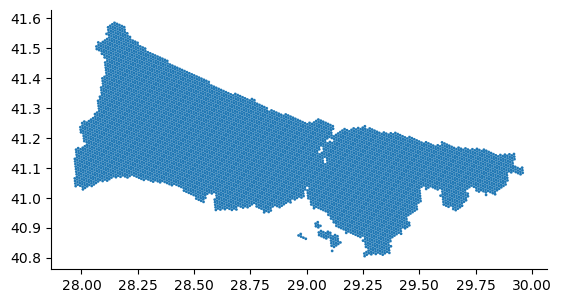

In [19]:
# We keep only the H3 hexagons of the AOI
gdf_h3_AOI = gpd.sjoin(gdf_h3, gdf_AOI, how="inner", predicate="intersects")
gdf_h3_AOI.plot();

**Apply the filtering**

In [21]:
# set-based filtering
set_h3_AOI = set(gdf_h3_AOI["h3_index"])
df_AOI = df[df["hex_id"].isin(set_h3_AOI)]

Visualize the map **BEFORE** and **AFTER** the spatial filtering

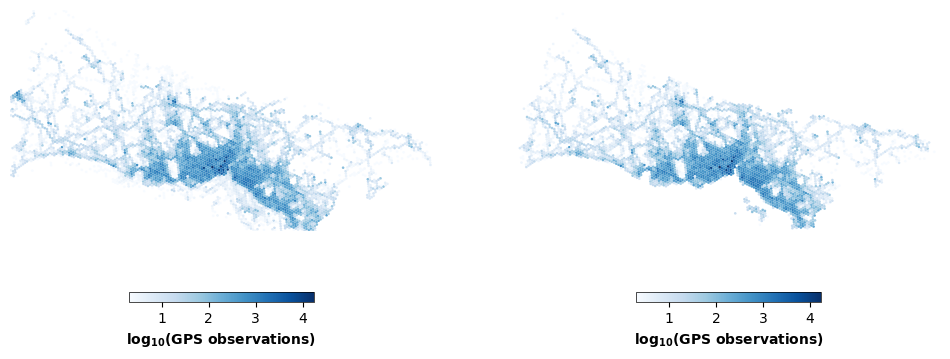

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Get global bounds from the full hex grid
xmin, ymin, xmax, ymax = gdf_h3_AOI.total_bounds

for ax, dplot in zip(axes, [df, df_AOI]):
    
    df_gb_count = dplot.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
    df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
    gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
    gdf_map["uid"] = gdf_map["uid"].fillna(0)
    _, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)
    
    ax.axis("off");
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
    cbar.outline.set_linewidth(0.5)  

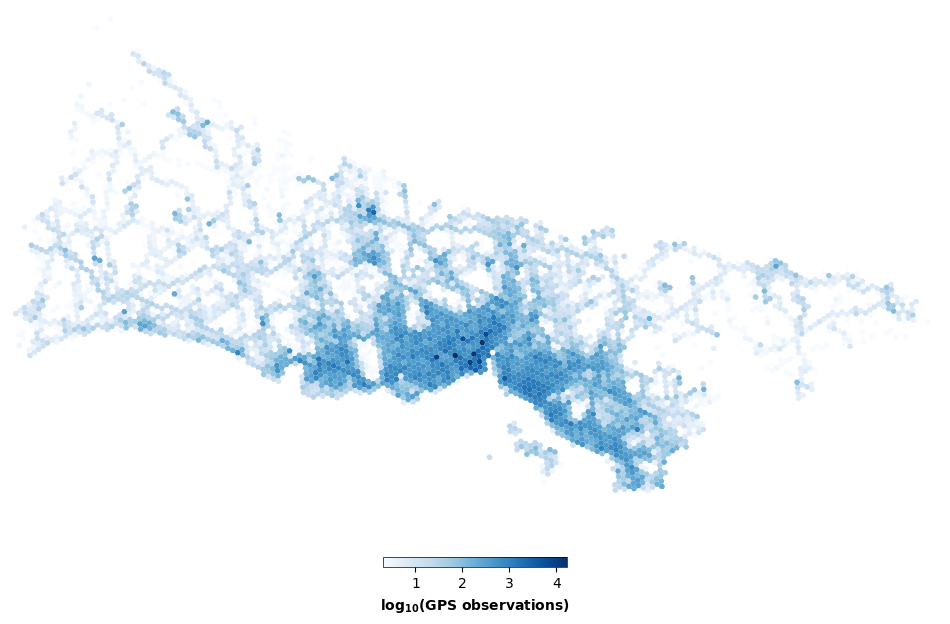

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))

df_gb_count = df_AOI.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map["uid"] = gdf_map["uid"].fillna(0)
_, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)
    
ax.axis("off");
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5)  

**Figure 2.** Spatial distribution of GPS observations shown as the average number of records per H3 hexagon (resolution 8). Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations.

In [24]:
print("# rows:", len(df_AOI))
print("# users:", df_AOI["uid"].nunique())
# Memory usage
mem_bytes = df_AOI.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 23109905
# users: 242399
3.62 GB


### 1.4 Preprocessing and filtering

To ensure data quality and reduce noise, we apply a set of preprocessing steps. Users with very low daily activity (fewer than three recorded points per day) are excluded, as they do not provide reliable information on spatial behavior.
In addition, H3 hexagons are retained only if they are consistently active throughout the observation period. Hexes with insufficient activity are removed to avoid unstable estimates and inflated Z-scores.

The final dataset consists of approximately 22,336,000 observations from 131,500 users covering 1,784 spatial units.

#TO COMPLETE As discussed in Section ZZZ, the main results are robust to variations in these filtering choices.

In [1]:
# Time series: Total Points, Unique Users, and Visited Hexes per Day
df_gb_stats_raw = (
    df_AOI.groupby("date")
      .agg(n_points_count=("uid", "count"), uid_unique=("uid", "nunique"),
           hex_id_unique=("hex_id", "nunique")).reset_index())

NameError: name 'df_AOI' is not defined

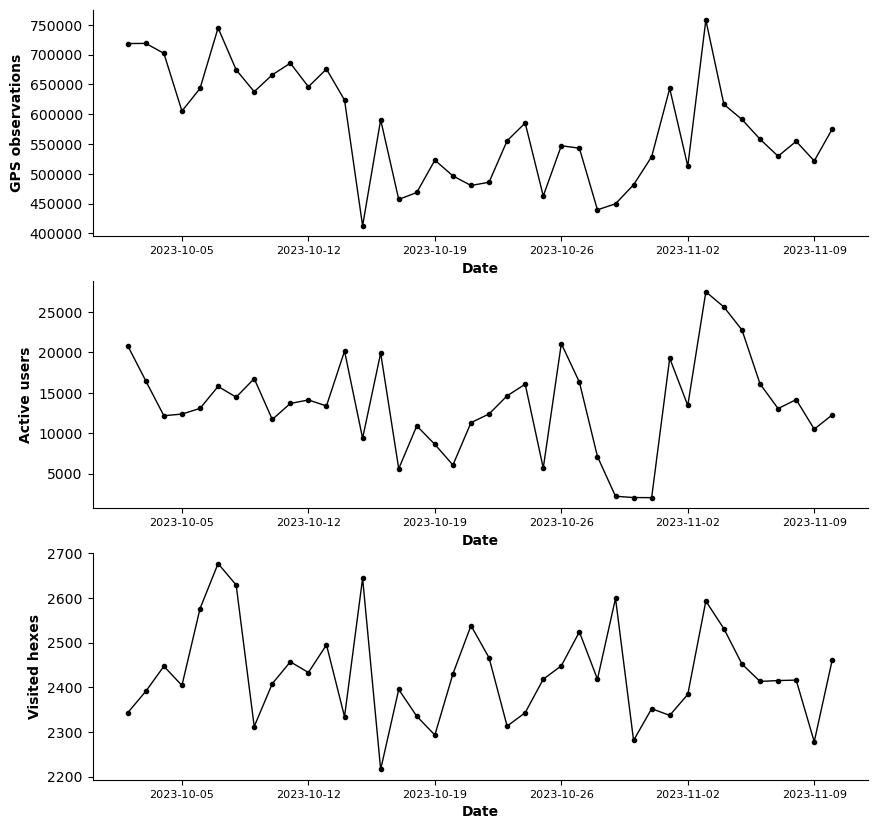

In [26]:
axes_ts = plot_time_series(df_gb_stats_raw, axes=None, color="k", plot_avg=False)
for ax in axes_ts:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)

In [27]:
list_gps_user_day = list(df_AOI.groupby(['uid', 'date']).size().reset_index(name='n_obs')["n_obs"])

print("--- Number of observations per user per day ---")
print("avg. ", round(np.mean(list_gps_user_day),2))
print("Q1", np.quantile(list_gps_user_day, .25))
print("median", np.quantile(list_gps_user_day, .5))
print("Q3", np.quantile(list_gps_user_day, .75))

--- Number of observations per user per day ---
avg.  42.74
Q1 1.0
median 3.0
Q3 11.0


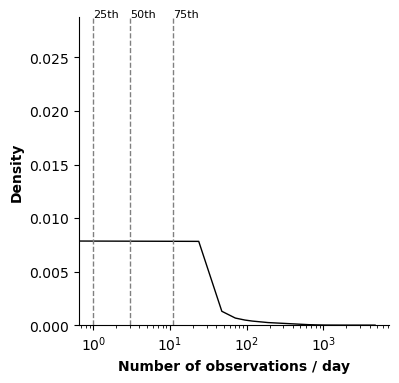

In [28]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.kdeplot(list_gps_user_day, clip=[0, None], c="k", linewidth=1)

p25 = np.quantile(list_gps_user_day, 0.25)
p50 = np.quantile(list_gps_user_day, 0.5)
p75 = np.quantile(list_gps_user_day, 0.75)

for p, label in zip([p25, p50, p75], ["25th", "50th", "75th"]):
    plt.axvline(p, c="grey", linestyle="--", linewidth=1)
    # Annotate the percentile near the line
    plt.text(p, plt.ylim()[1], f"{label}", rotation=0, color='k', fontsize=8)

plt.xscale("log")
ax.set_xlabel("Number of observations / day", weight=600)
ax.set_ylabel("Density", weight=600);

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

_ = plot_time_series(df_gb_stats_raw, axes=axes, color="k", plot_avg=False, label="raw")

user_min_points = [2, 3, 5, 10]

palette = sns.color_palette("viridis", n_colors=len(user_min_points))

for user_th, col in zip(user_min_points, palette):

    df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= user_th]
    
    df_gb_stats_filtered = (
    df_filtered_u.groupby("date")
              .agg(
                  n_points_count=("uid", "count"),uid_unique=("uid", "nunique"),
                  hex_id_unique=("hex_id", "nunique")).reset_index())

    del df_filtered_u
    _ = plot_time_series(df_gb_stats_filtered, axes=axes, color=col,
                         plot_avg=False, label=f"U >= {user_th} points")
    '''
    print(f"CV users with >= {user_th} points")
    print("Points: ", coefficient_of_variation(df_gb_stats_filtered["n_points_count"]))
    print("Users: ", coefficient_of_variation(df_gb_stats_filtered["uid_unique"]))
    print("Hexes: ", coefficient_of_variation(df_gb_stats_filtered["hex_id_unique"]))
    print()
    '''

axes[0].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600);

## 2. Methods

### 2.1 Urban Space Usage Index

To capture spatial activity at a daily resolution, we use the **Urban Space Usage Index** ($I$), defined as the number of unique users visiting each H3 hexagon normalized by the total number of active users on that day:

$$ I_{h,d} = \frac{U_{h,d}}{U_d} $$

where $U_{h,d}$ is the number of unique users in hexagon $h$ on day $d$, and $U_d$ is the total number of active users on day $d$.

The index can be interpreted as the share of total observed activity occurring in each hexagon.  The number of unique users is used as a proxy for human presence, assuming that higher user counts correspond to greater spatial utilization. For more details on the index, please refer to the {doc}`Methodology`.

### 2.2 Deviation Measurement (Z-score)

To identify event-driven deviations, we define a baseline period using pre-event days (2-27 October 2023). For each hexagon, we compute the baseline mean and standard deviation of the Urban Space Usage Index.

Deviations from typical conditions are quantified using a Z-score, computed for each hexagon and day as:

$$Z_{h,d} = \frac{I_{h,d} - \mu_h}{\sigma_h}$$

where $\mu_h$ and $\sigma_h$ are the average and standard deviation of $I_{h,d}$ during the baseline period, respectively.

The Z-score measures how strongly observed activity deviates from expected baseline levels. Positive values indicate higher-than-expected activity, while negative values indicate lower-than-expected activity relative to baseline conditions. The magnitude (i.e., absolute value) of the Z-score reflects the strength of the deviation, with larger values indicating more pronounced anomalies.

**Filter 1:** Remove users per day who do not meet the minimum number of GPS points threshold (noise users).

In [31]:
# filtering parameters
# tip: we can use the median value, it seems robust to me
min_points_per_day = 3

df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= min_points_per_day]

print(f"min points/day: {min_points_per_day}")
print(f"# GPS points: {len(df_filtered_u)} ({len(df_AOI)-len(df_filtered_u)} points removed)")
print("# unique users", df_filtered_u["uid"].nunique())

min points/day: 3
# GPS points: 22776569 (333336 points removed)
# unique users 131832


Compute the Urban Space Index
Let's create a dataframe in which:
- each **row** is an **hex**
- each **column** refers to a **day**
- each cell is the number of unique users that visit an hex on a given day (ACTIVITY)

In [2]:
ts_ACTIVITY = df_filtered_u.groupby(["hex_id", "date"])["uid"].nunique().unstack(fill_value=0)
ts_ACTIVITY[:3]

NameError: name 'df_filtered_u' is not defined

Filter 2: Remove hexes that do not meet the minimum activity threshold across a sufficient share of days.

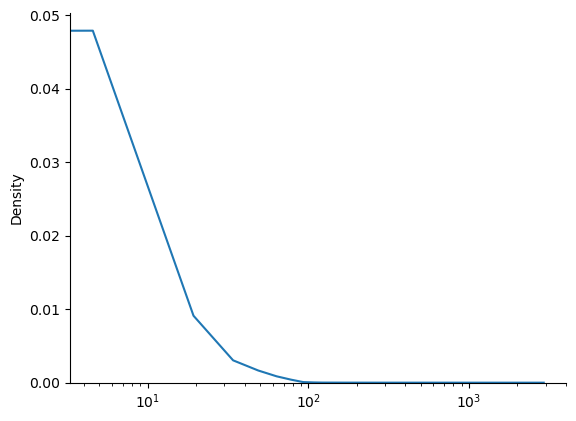

In [41]:
values_list = ts_ACTIVITY.to_numpy().ravel().tolist()
sns.kdeplot(values_list)
plt.xscale("log")

In [42]:
k = 0                # minimum observations per day
x_percent = .95        # e.g., x% of days required

# total number of days (columns)
total_days = ts_ACTIVITY.shape[1]

# minimum number of valid days required
min_days_required = x_percent * total_days

# count how many days per hex exceed k
valid_days_per_hex = (ts_ACTIVITY > k).sum(axis=1)

# filter
ts_ACTIVITY_filtered = ts_ACTIVITY[valid_days_per_hex >= min_days_required]

print("total number of hexes:", len(ts_ACTIVITY_filtered))
print("removed hexes:", len(ts_ACTIVITY) - len(ts_ACTIVITY_filtered))

total number of hexes: 1784
removed hexes: 2536


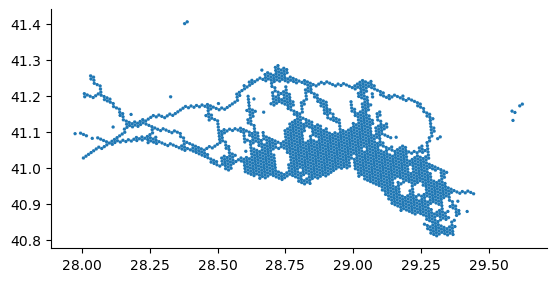

In [43]:
gdf_h3[gdf_h3["h3_index"].isin(ts_ACTIVITY_filtered.index)].plot()
ax.axis("off");

**Compute the number of unique users that visit an hex on a given day (to normalize ACTIVITY)**

The normalized activity is also referret to as "Urban Space Usage Index" (or, $I$)

In [44]:
total_unique_users = df_filtered_u.groupby("date")["uid"].nunique()
ts_USI = ts_ACTIVITY_filtered / total_unique_users

#ts_ACTIVITY_norm = 100*(ts_ACTIVITY_filtered / total_unique_users)
#ts_ACTIVITY_norm = (ts_ACTIVITY_norm - ts_ACTIVITY_norm.min()) / (ts_ACTIVITY_norm.max() - ts_ACTIVITY_norm.min())
ts_USI[:1]

date,2023-10-02,2023-10-03,2023-10-04,2023-10-05,2023-10-06,2023-10-07,2023-10-08,2023-10-09,2023-10-10,2023-10-11,2023-10-12,2023-10-13,2023-10-14,2023-10-15,2023-10-16,2023-10-17,2023-10-18,2023-10-19,2023-10-20,2023-10-21,2023-10-22,2023-10-23,2023-10-24,2023-10-25,2023-10-26,2023-10-27,2023-10-28,2023-10-29,2023-10-30,2023-10-31,2023-11-01,2023-11-02,2023-11-03,2023-11-04,2023-11-05,2023-11-06,2023-11-07,2023-11-08,2023-11-09,2023-11-10
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
881ec832b3fffff,0.000245,0.000303,0.000394,0.000266,0.000919,0.000846,0.001107,0.000441,0.00074,0.000578,0.000819,0.000844,0.000772,0.001456,0.000538,0.001097,0.000379,0.000259,0.001275,0.000968,0.001196,0.001133,0.000878,0.001453,0.000228,0.001335,0.002379,0.00369,0.001576,0.002632,0.000229,0.00044,0.000226,0.000866,0.000371,0.001036,0.000958,0.00077,0.000154,0.000386


## 3. Results

Text(0, 0.5, 'normalized Hex Activity (# users)')

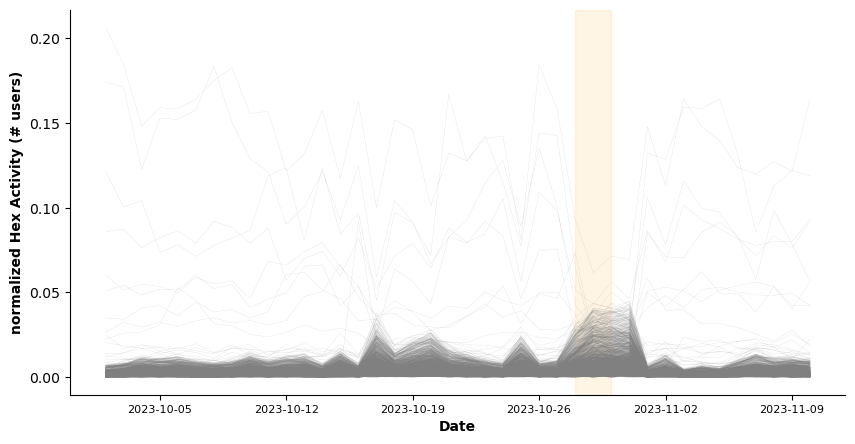

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for hex_id in ts_USI.index:
    ax.plot(ts_USI.columns, ts_USI.loc[hex_id], alpha=0.6, linewidth=0.1, color="grey")

#ax.plot(ts.mean(), c="k")

# ax.axvline(pd.to_datetime("2023-10-28 00:00"), color="k", linestyle="--", linewidth=0.5)
# ax.axvline(pd.to_datetime("2023-10-29 23:59"), color="k", linestyle="--", linewidth=0.5)

ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1)

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("normalized Hex Activity (# users)", weight=600)
#plt.ylim(0, 200);

### 3.1 Temporal evolution of urban activity

The temporal evolution of the Urban Space Usage Index shows a noticeable shift in urban activity during the event period compared to typical conditions (see Figure 3). Activity levels rise in the days leading up to the event, peak on the event day, and decline shortly thereafter. As expected for a large planned event, this pattern suggests anticipatory and residual mobility effects, likely driven by preparation activities, public gatherings, and increased presence in central areas.

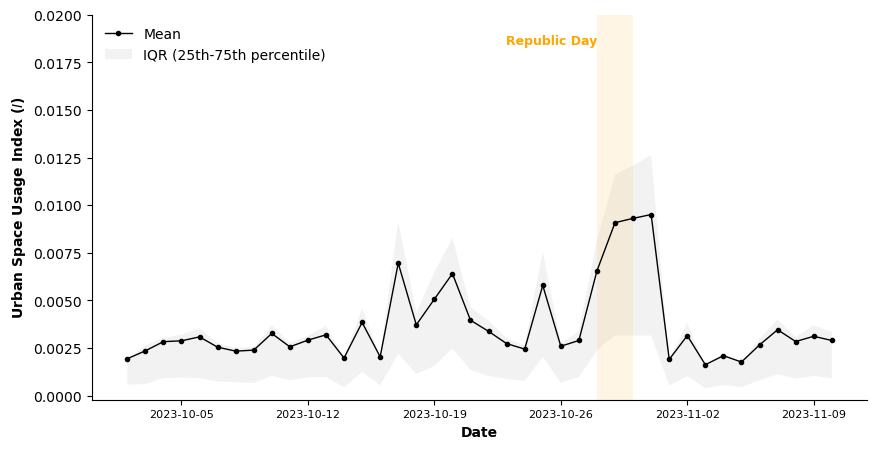

In [47]:
# Assuming ts_ACTIVITY_norm is your DataFrame with time series data
# Calculate the mean and IQR
mean_values = ts_USI.mean(axis=0)
q25 = ts_USI.quantile(0.25, axis=0)
q75 = ts_USI.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(ts_USI.columns, mean_values, c="k", label="Mean", linewidth=1, marker=".")

# Plot the shaded area for the IQR
ax.fill_between(ts_USI.columns, q25, q75, color="grey", alpha=0.1, label="IQR (25th-75th percentile)", edgecolor="none")

# Highlight the event span
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.95, "Republic Day", color="orange", transform=ax.get_xaxis_transform(), fontsize=9,
        weight="bold", va="top", ha="right")#, bbox=dict(facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))


# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Urban Space Usage Index ($I$)", weight=600)

ax.set_ylim(None, 0.02)

# Add a legend
ax.legend();

**Figure 3.** Time series of the average Urban Space Usage Index (I) across all hexagonal cells in Istanbul, with shaded area representing the interquartile range. The highlighted band marks the Republic Day period (28–29 October), during which a clear increase in activity is observed.

### 3.2 Anomaly detection

To assess whether changes in activity correspond to statistically significant deviations from typical conditions, we use the Z-score, which measures how many standard deviations observed activity deviates from its baseline.

As shown in Figure 4, during the **baseline period**, as expected, **Z-scores fluctuate around zero**, indicating stable activity levels. Two localized positive peaks are observed in mid-October, which may be associated with known protest events and reflect short-lived increases in mobility (see, e.g., [EFE, 18 Oct 2023](https://efe.com/en/latest-news/2023-10-18/more-than-60-injured-in-anti-israel-protests-in-turkey/) and [Balkan Insight, 20 Oct 2023](https://balkaninsight.com/2023/10/20/pro-palestine-protests-rock-turkey-as-israel-withdraws-diplomats/))


The **Republic Day event** exhibits a clear **increase in Z-score**, beginning in the days preceding the event and peaking during the main celebration.

On 28 October, the day preceding Republic Day main event, the average Z-score rises from -0.2 to 2.13, indicating a positive deviation from baseline conditions and marking the start of increased activity.
On the main event day, 29 October (Republic Day), the average Z-score is 4.05, indicating an extreme positive anomaly due to increased activity relative to normal conditions. This peak is markedly higher than all other fluctuations observed in the time series.

On the day following the event, Z-scores remain elevated, likely reflecting continued celebrations extending past midnight and into the following day. On 31 October, the Z-score rapidly declines, returning to values close to zero.

This quick recovery toward typical mobility patterns suggests that the observed temporary disruption is closely associated with the Republic Day event.

In [48]:
baseline = ts_USI.loc[:, "2023-10-01":"2023-10-27"]
baseline_mean = baseline.mean(axis=1)
baseline_std = baseline.std(axis=1)

In [49]:
# subtraction and division row-wise to compute the z-score
z_scores = ts_USI.sub(baseline_mean, axis=0).div(baseline_std, axis=0)
z_scores = z_scores.dropna()

z_scores[:1]

date,2023-10-02,2023-10-03,2023-10-04,2023-10-05,2023-10-06,2023-10-07,2023-10-08,2023-10-09,2023-10-10,2023-10-11,2023-10-12,2023-10-13,2023-10-14,2023-10-15,2023-10-16,2023-10-17,2023-10-18,2023-10-19,2023-10-20,2023-10-21,2023-10-22,2023-10-23,2023-10-24,2023-10-25,2023-10-26,2023-10-27,2023-10-28,2023-10-29,2023-10-30,2023-10-31,2023-11-01,2023-11-02,2023-11-03,2023-11-04,2023-11-05,2023-11-06,2023-11-07,2023-11-08,2023-11-09,2023-11-10
hex_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
881ec832b3fffff,-1.369923,-1.221612,-0.993289,-1.315227,0.332976,0.148625,0.807071,-0.873228,-0.120506,-0.529341,0.08129,0.142091,-0.037852,1.687717,-0.62974,0.781894,-1.032193,-1.333958,1.231915,0.457025,1.031565,0.872898,0.23027,1.681307,-1.413228,1.383453,4.020327,7.330127,1.990808,4.657299,-1.410973,-0.875888,-1.417513,0.199373,-1.050225,0.628207,0.430795,-0.042526,-1.600091,-1.012376


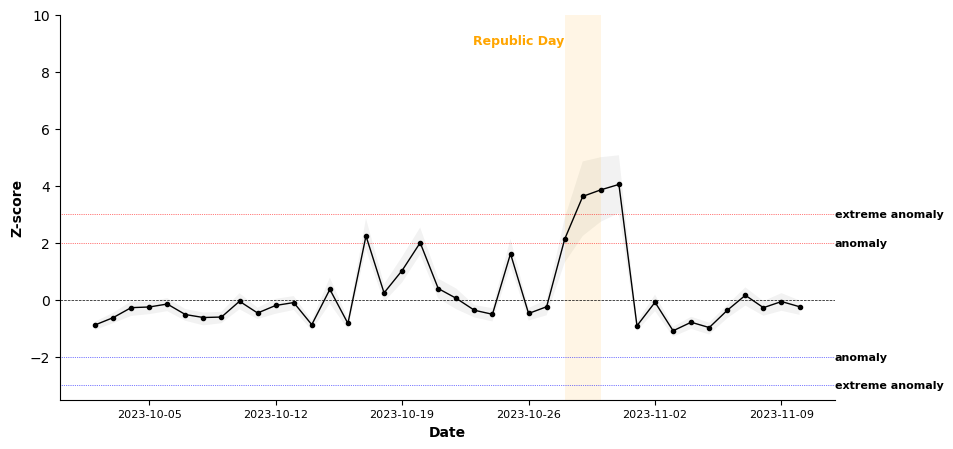

In [51]:
mean_values = z_scores.mean(axis=0)
q25 = z_scores.quantile(0.25, axis=0)
q75 = z_scores.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# --- Plot all series at once ---
#ax.plot(x, y.T, color="grey", alpha=0.15, linewidth=0.5)

# Plot the mean line
ax.plot(z_scores.mean(), c="k", linewidth=1, zorder=99, marker=".")  # average line

# Plot the shaded area for the IQR with no border
ax.fill_between(z_scores.columns, q25, q75, color="grey", alpha=0.1, edgecolor="none", label="IQR (25th-75th percentile)")

# Add horizontal line at 0
ax.axhline(0, c="k", linewidth=.5, linestyle="--")

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---
for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.5, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.5, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    

# Highlight the event span
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.95, "Republic Day", color="orange", transform=ax.get_xaxis_transform(), fontsize=9,
        weight="bold", va="top", ha="right")#, bbox=dict(facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))
# --- Annotating events ---
dict_events = [(pd.to_datetime("2023-10-17"), "Anti-Israel protests"),
               (pd.to_datetime("2023-10-20"), "Pro-Palestine protests")]

dict_events = []

for event_when, event_what in dict_events:
    x_arrow = event_when
    y_start = 4
    y_end = 3
    
    ax.annotate(event_what, xy=(x_arrow, y_end),  xytext=(x_arrow, y_start),
                ha='center', va='bottom', rotation=90, fontsize=8,
                arrowprops=dict(
                    arrowstyle='->',
                    color='black',
                    linewidth=1.5
                ),
                color='black')

# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)

# Optional: limit y-axis if necessary
plt.ylim(-3.5, 10)

plt.show()

**Figure 4.** Time series of the average Z-score of the Urban Space Usage Index across hexagons in Istanbul, with shaded area representing the interquartile range. Horizontal dashed lines indicate anomaly thresholds. The highlighted band marks the Republic Day period (28–29 October), during which activity reaches extreme positive deviations.

In [ ]:
z_scores.mean(axis=0).reset_index()

### 3.3 Spatial distribution of anomalies

The map in Figure 5 illustrates the spatial distribution of Z-scores across hexagonal cells on 29 October (Republic Day). It shows that the increase in activity is not confined to specific locations but is instead widely distributed across the metropolitan area of Istanbul, including airport areas and major road infrastructure. This pattern confirms that the anomaly is spatially diffuse, affecting both central areas and peripheral zones.

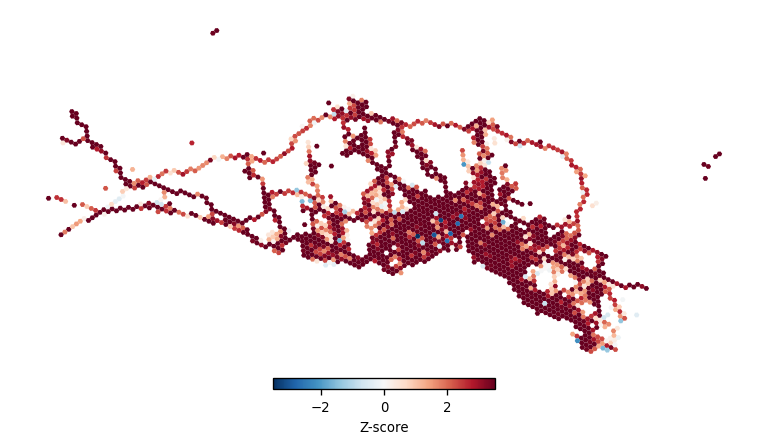

In [63]:
day_plot = "2023-10-29"

df_gdf_zscore = z_scores[[day_plot]].copy()
df_gdf_zscore["z_score"] = df_gdf_zscore[day_plot]
df_gdf_zscore_plot = df_gdf_zscore[["z_score"]]

vmax = 3.5
vmin =-vmax

gdf_map_zscore = gdf_h3.merge(df_gdf_zscore_plot, left_on="h3_index", right_on="hex_id", how="inner")

fig, ax = plt.subplots(figsize=(8,8), dpi=120)
gdf_map_zscore.plot(column="z_score", cmap="RdBu_r", legend=False, ax=ax, vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin, vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.01, orientation="horizontal")
cbar.set_label("Z-score", fontsize=8)
cbar.ax.tick_params(labelsize=8)
ax.axis("off");

**Figure 5.** Map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in Istanbul on 29 October 2023. Warmer colors indicate higher-than-expected activity, showing a widespread increase across the metropolitan area.

We further examine the evolution of Z-scores over the entire observation period. During the baseline phase, Z-scores remain close to zero. On Republic Day, the map becomes uniformly dominated by high values. Following the event, Z-scores rapidly decline, returning to baseline levels consistent with typical mobility patterns (Figure 6).

In [4]:
from IPython.display import HTML
HTML('<iframe width="100%" height="800px" src="https://studio.foursquare.com/map/public/a8286dcf-38fc-4fbc-9a14-d9124ac438c7/embed" frameborder="0" allowfullscreen></iframe>')

**Figure 6.** Interactive map of Z-score of the Urban Space Usage Index across H3 hexagonal cells in Istanbul. The animation shows the day-by-day evolution of activity levels, with colors indicating relative intensity. The play control allows exploration of temporal dynamics before, during, and after Republic Day.

### 3.4 Spatial and Functional Characterization of Activity

To interpret the spatial distribution of activity, each hexagonal cell is associated with two complementary dimensions: land use and functional activity (Points of Interest, POIs).
Land use is derived from OpenStreetMap (OSM) data and assigns each hexagon a dominant category (e.g., residential, commercial, industrial, green areas), capturing the physical organization of urban space. In contrast, the functional layer is derived from Points of Interest (POIs). For each hexagon, we count the number of POIs in different activity categories (e.g., schools, hospitals, parks, transport hubs, commercial venues).

#### Land Use Analysis

All categories exhibit a substantial increase in activity during the event, with average Z-scores above 2.5. The simultaneous increase further indicates that the anomaly is spatially diffuse rather than localized and affects the entire urban system.

**Residential (Z ≈ 3.13)** and **commercial areas (Z ≈ 3.10)** show the strongest deviations, suggesting that the event impacts both living spaces and economic centers. In contrast, **industrial (Z ≈ 2.50)** and construction areas **(Z ≈ 2.60)** exhibit more moderate increases.

These patterns are consistent with changes in absolute activity levels. Commercial areas, for instance, more than double their $I$ (from 0.0051 to 0.0119), while residential areas show a similarly strong relative increase (from 0.0039 to 0.0094), confirming a broad intensification of both social and economic activity.

|   Land Use   | Z-score (event) | I (event) | I (baseline) |
|:------------:|:---------------:|:---------:|:------------:|
| commercial   |     3.095207    |  0.011937 |   0.005151   |
| industrial   |     2.500915    |  0.008471 |   0.004947   |
| construction |     2.602213    |  0.010348 |   0.003893   |
| residential  |     3.130038    |  0.009431 |   0.003864   |
| green        |     2.674649    |  0.006753 |   0.002677   |
| water        |     3.014815    |  0.005555 |   0.002297   |
| other        |     2.768250    |  0.005468 |   0.002118   |
| farmland     |     2.766256    |  0.005283 |   0.002003   |

#### Functional (POI-Based) Analysis

We then examine activity across functional layers derived from POIs. All categories display consistently high Z-scores (≈ 2.7-3.4), indicating that the increase in activity spans multiple urban functions rather than being concentrated in specific sectors.

**Transport hubs**, particularly train stations (Z ≈ 3.44), **show the highest anomaly**, highlighting increased mobility flows across the city. Hospitals (Z ≈ 3.36) and tourism-related locations (Z ≈ 3.28) also exhibit strong deviations. Commercial and social venues (including malls, restaurants, and shops) register Z-scores above 3. Infrastructure elements such as highways (Z ≈ 2.72) show comparatively lower anomalies, reflecting their role as transit corridors rather than primary destinations.

Several categories more than double their baseline $I$ levels. For example, train stations (from 0.0057 to 0.0144) and malls (from 0.0071 to 0.0144).

|    POI layer   | Z-score (event) | _I_ (event) | _I_ (baseline) |
|:--------------:|:------------:|:--------------:|:-------------:|
| malls          |   3.064736   |    0.014427    |    0.007120   |
| universities   |   2.952261   |    0.014049    |    0.006153   |
| tourism        |   3.279846   |    0.013250    |    0.006083   |
| hospitals      |   3.358994   |    0.013429    |    0.005956   |
| train stations |   3.435939   |    0.014381    |    0.005667   |
| restaurants    |   3.165840   |    0.010430    |    0.004595   |
| offices        |   3.125214   |    0.010562    |    0.004420   |
| shops          |   3.082928   |    0.009911    |    0.004304   |
| schools        |   3.094937   |    0.009930    |    0.004140   |
| highways       |   2.717708   |    0.009919    |    0.003919   |
| parks          |   3.234622   |    0.009412    |    0.003514   |
| airports       |   2.922234   |    0.006594    |    0.002397   |

In [52]:
gdf_h3_landuse =  gpd.read_file(f"./shape_files/landuse_poi_h3_8_istanbul.gpkg")
#gdf_h3_landuse = gdf_h3_landuse[["h3_index", "context_label", "poi_label"]]

gdf_h3_landuse_geo = gdf_h3_landuse.copy()

#gdf_h3_landuse = gdf_h3_landuse[["h3_index", "land_use", "poi_label",]]

In [53]:
z_scores_baseline = z_scores.loc[:, "2023-10-01":"2023-10-27"]
z_scores_event = z_scores.loc[:, "2023-10-28":"2023-10-29"]

activity_baseline = ts_USI.loc[:, "2023-10-01":"2023-10-27"]
activity_event = ts_USI.loc[:, "2023-10-28":"2023-10-29"]

In [54]:
# Step 1: rename key
gdf_h3_landuse = gdf_h3_landuse.rename(columns={"h3_index": "hex_id"})

# Step 2: compute means and keep hex_id
z_base_mean = z_scores_baseline.mean(axis=1).to_frame("z_base_mean").reset_index()
z_event_mean = z_scores_event.mean(axis=1).to_frame("z_event_mean").reset_index()
act_base_mean = activity_baseline.mean(axis=1).to_frame("act_base_mean").reset_index()
act_event_mean = activity_event.mean(axis=1).to_frame("act_event_mean").reset_index()

# Step 3: merge everything
gdf_hex_scores_LU = (
    gdf_h3_landuse
    .merge(z_base_mean, on="hex_id", how="left")
    .merge(z_event_mean, on="hex_id", how="left")
    .merge(act_base_mean, on="hex_id", how="left")
    .merge(act_event_mean, on="hex_id", how="left")
)

gdf_hex_scores_LU = gdf_hex_scores_LU.dropna(subset=["z_base_mean"])

len(gdf_hex_scores_LU)

1784

Land usage 

In [56]:
landuse_colors = {
"residential": "#F4A261",
"commercial": "#E76F51",
"industrial": "#6D597A",
"education": "blue",
"construction": "darkgrey",
"farmland": "#90BE6D",
"green": "#2A9D8F",
"water": "#4A90E2",
"other": "#EEEEEE"
}

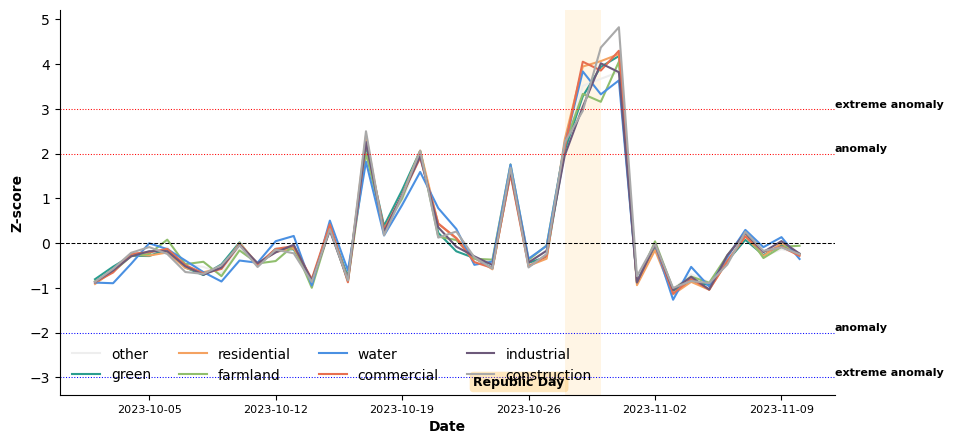

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

label_col = "land_use"

gdf_filtered = gdf_h3_landuse[gdf_h3_landuse[label_col]!="other"]
gdf_filtered = gdf_h3_landuse[gdf_h3_landuse[label_col]!="none"]
gdf_filtered = gdf_filtered.dropna(subset=[label_col])

for category in gdf_filtered[label_col].unique():
    
    h3_in_category = set(gdf_filtered[gdf_filtered[label_col]==category]["hex_id"])
    z_scores_category = z_scores[z_scores.index.isin(h3_in_category)]

    x = pd.to_datetime(z_scores_category.columns)
    y = z_scores_category.values
    
    # --- Plot all series at once  ---
    #ax.plot(x, y.T, color="grey", alpha=0.15, linewidth=0.5)
    if label_col == "land_use":
        color = landuse_colors[category]
    else:
        color = poi_colors[category]
        
    ax.plot(z_scores_category.mean(), label=category, color=color)


# --- Event window shading ---
ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.05, "Republic Day", transform=ax.get_xaxis_transform() ,fontsize=9,
        weight="bold", va="top", ha="right", bbox=dict(
    facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))

plt.legend(ncol=4)

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---

for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.75, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.75, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th + 0.1, anomaly_label, ha="left", va="center", weight=600, size=8)


ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)
ax.axhline(0, c="k", linewidth=.75, linestyle="--")

In [58]:
gdf_hex_scores_LU.groupby("land_use")[["z_event_mean", "act_event_mean", "act_base_mean"]].mean(
    ).sort_values("act_base_mean", ascending=False)

,z_event_mean,act_event_mean,act_base_mean
land_use,,,
commercial,3.095207,0.011937,0.005151
industrial,2.500915,0.008471,0.004947
construction,2.602213,0.010348,0.003893
residential,3.130038,0.009431,0.003864
green,2.674649,0.006753,0.002677
water,3.014815,0.005555,0.002297
other,2.768250,0.005468,0.002118
farmland,2.766256,0.005283,0.002003


Time series mean activity per layer

In [59]:
layers_POI = ['is_highway', 'n_airports', 'n_hospitals', 'n_malls', 'n_offices', 'n_restaurants', 'n_schools',
            'n_shops', 'n_tourism', 'n_train_stations', 'n_universities', 'n_parks']

Text(0, 0.5, 'Avg. I of layer n_parks')

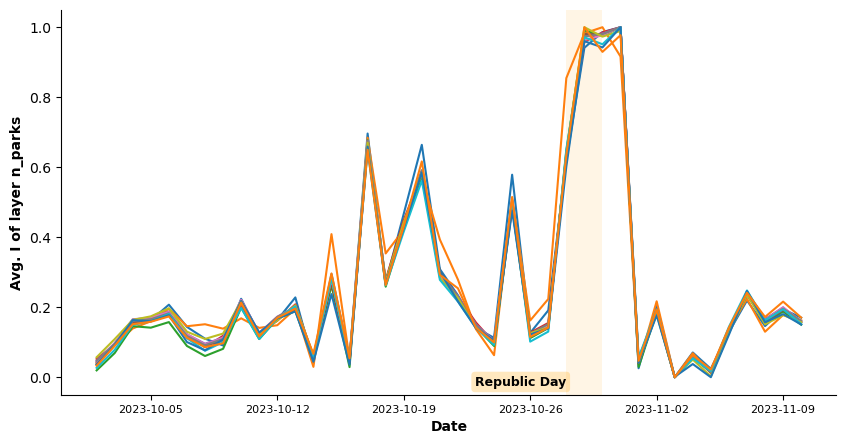

In [60]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for layer in layers_POI:
    
    h3_in_layer = set(gdf_h3_landuse[gdf_h3_landuse[layer]>0]["hex_id"])
    activity_norm_layer = ts_USI[ts_USI.index.isin(h3_in_layer)]
    
    x = pd.to_datetime(activity_norm_layer.columns)
    y = min_max_normalize_range(activity_norm_layer.mean().values)
    
    ax.plot(x,y, label=layer)

ax.axvspan(EVENT_START, EVENT_END, color="orange", alpha=0.1, linewidth=0)
ax.text(EVENT_START, 0.05, "Republic Day", transform=ax.get_xaxis_transform() ,fontsize=9,
        weight="bold", va="top", ha="right", bbox=dict(
    facecolor="orange", edgecolor="none", boxstyle="round,pad=0.3", alpha=0.25))

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel(f"Avg. I of layer {layer}", weight=600)
#ax.axhline(0, c="k", linewidth=.75, linestyle="--")

#ax.set_xlim(pd.to_datetime("2023-10-28"), pd.to_datetime("2023-10-31"))

They are perfectly "synchronized"

In [61]:
rows = []

for layer in layers_POI:
    avg_scores_in_layer = (
        gdf_hex_scores_LU[gdf_hex_scores_LU[layer] > 0]
        [["z_event_mean", "act_event_mean", "act_base_mean"]]
        .mean()
    )
    
    # Convert to dict and add layer name
    row = avg_scores_in_layer.to_dict()
    row["layer"] = layer
    
    rows.append(row)

# Create DataFrame
pd.DataFrame(rows).set_index("layer").sort_values("act_base_mean", ascending=False)

,z_event_mean,act_event_mean,act_base_mean
layer,,,
n_malls,3.064736,0.014427,0.007120
n_universities,2.952261,0.014049,0.006153
n_tourism,3.279846,0.013250,0.006083
n_hospitals,3.358994,0.013429,0.005956
n_train_stations,3.435939,0.014381,0.005667
n_restaurants,3.165840,0.010430,0.004595
n_offices,3.125214,0.010562,0.004420
n_shops,3.082928,0.009911,0.004304
n_schools,3.094937,0.009930,0.004140


## 4. Conclusions and Key Findings

This analysis quantifies the impact of the planned event Republic Day on urban activity patterns in Istanbul using anonymized mobility data and the Urban Space Usage Index.

The main findings are:

**1.** Urban activity increases in the days leading up to the event, peaks on Republic Day, and rapidly returns to baseline levels, indicating that the observed changes are closely associated with the event.

**2.** Z-scores reveal a statistically significant increase in activity during the event, with values reaching extreme anomaly levels relative to baseline conditions.

**3.** The increase in activity is distributed across the metropolitan area and observed across all land use types and functional layers. While some differences emerge, these variations are relatively modest.

Overall, these results demonstrate that the proposed framework can effectively detect and characterize anomalous periods of urban activity.

## Limitations
This analysis is subject to some limitations. Mobility data may not fully represent the entire population, as it depends on smartphone usage and data coverage. In addition, spatial aggregation into H3 cells may smooth local variations.